# Heat Loss Simulation of PTES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error
from IPython.display import clear_output

The following functions (data_import(), PTES_geometry_import()) are used to import the data (temperature, storage content, energy in and out) and the geometry of the pit storage. The Excel file from which data is imported must have a specific structure. Specified in the comments of the two functions.

The data source for the two pit storages simulated in this jupyter notebook:

Dronninglund:
- https://doi.org/10.1016/j.solener.2022.12.046 with data on github: https://github.com/PitStorages/DronninglundData
- (for missing data on github) https://planenergi.eu/wp-content/uploads/2023/09/SUNSTORE-3-Phase-2-Implementation.pdf

Hoje Taastrup:
- https://doi.org/10.1016/j.est.2025.117504 with data on github: https://github.com/PitStorages/HojeTaastrupData/tree/1.1

In [45]:
def data_import(file_path):
    '''Imports data from an Excel file and returns a DataFrame

    Structure of the Excel file:

    Sheet 1: 'data' contains the following columns:
    - time: Date and Time
    - Q_storage (NEEDED FOR VALIDATION. FOR SIMULATION ONLY THE INITIAL VALUE IS NEEDED): Energy content of the storage (MWh)
    - Q_charge: Energy charged into the storage (MWh)
    - Q_discharge: Energy discharged from the storage (MWh)
    - T_air: Air temperature at the storage location (°C)
    - T_soil: Soil temperature at the storage location (°C)
    - T_XX (NEEDED FOR VALIDATION. FOR SIMULATION TEMPERATURE MAP IS USED): Temperature at different heights (increasing from bottom to top XX = 01, 02, ...) in the storage (°C)
    
    Sheet 2: 'geometry' contains the following columns:
    - h: Height of the truncated pyramid (m)
    - a: Length of the upper rectangle (m)
    - b: Width of the upper rectangle (m)
    - c: Length of the lower rectangle (m)
    - d: Width of the lower rectangle (m)'''

    # data import
    df_data = pd.read_excel(file_path, sheet_name='data')
    df_data.set_index(df_data.columns[0], inplace=True)
    df_data.index = pd.to_datetime(df_data.index)

    return df_data

In [46]:
def PTES_geometry_import(file_path):
    '''Imports geometry data from an Excel file and returns the parameters
    
    Structure of the Excel file:

    Sheet 1: 'data' contains the following columns:
    - time: Date and Time
    - Q_storage: Energy content of the storage (MWh)
    - Q_charge: Energy charged into the storage (MWh)
    - Q_discharge: Energy discharged from the storage (MWh)
    - T_air: Air temperature at the storage location (°C)
    - T_soil: Soil temperature at the storage location (°C)
    - T_XX: Temperature at different heights (increasing from bottom to top XX = 01, 02, ...) in the storage (°C)
    
    Sheet 2: 'geometry' contains the following columns:
    - h: Height of the truncated pyramid (m)
    - a: Length of the upper rectangle (m)
    - b: Width of the upper rectangle (m)
    - c: Length of the lower rectangle (m)
    - d: Width of the lower rectangle (m)'''

    # geometry import
    df_geometry = pd.read_excel(file_path, sheet_name='geometry')
    h = df_geometry['h'][0]
    a = df_geometry['a'][0]
    b = df_geometry['b'][0]
    c = df_geometry['c'][0]
    d = df_geometry['d'][0]

    return h, a, b, c, d

The next two functions are used for the properties of water (c_p = specific heat capacity, rho = density).

In [47]:
def density_water(T):
    '''Density (rho) of water in kg/m^3 based on fluid temperature (T) nearest the flow meter in degrees Celsius (https://github.com/PitStorages/DronninglundData)'''
    rho = (999.85+5.332*(10**-2)*T-7.564*(10**-3)*(T**2)+4.323*(10**-5)*(T**3)-1.673*(10**-7)*(T**4)+2.447*(10**-10)*(T**5))
    return(rho)

def specific_heat_water(T):
    '''Specific heat (cp) of water in J/(kg K) based on mean fluid temperature (T) in degrees Celsius (https://github.com/PitStorages/DronninglundData)'''
    cp = (4.2184-2.8218*(10**-3)*T+7.3478*(10**-5)*(T**2)-9.4712*(10**-7)*(T**3)+7.2869*(10**-9)*(T**4)-2.8098*(10**-11)*(T**5)
          +4.4008*(10**-14)*(T**6))*1000
    return(cp)

A class for STES objects is defined. There are subclasses for PTES and TTES.

In [48]:
class STES:
    """
    Abstract base class for seasonal thermal energy storage (STES) models.

    Provides shared attributes and methods for geometry-specific subclasses
    (e.g. PTES for pit storage, TTES for tank storage). Subclasses must
    define the geometry-dependent attributes (volumes, areas) in their
    own __init__ before calling compute_energy_bounds().
    """

    def __init__(self, n_layers, T_min=12, T_max=90, T_ref=10):
        """
        Parameters
        ----------
        n_layers : int
            Number of horizontal layers used to discretize the storage volume.
            Corresponds to the number of temperature sensors in a real installation.
        T_min : float
            Minimum (cold) storage temperature [°C].
        T_max : float
            Maximum (hot) storage temperature [°C].
        T_ref : float
            Reference temperature for calculating stored energy content [°C].
            Typically the undisturbed ground or mains water temperature.
        """

        self.n_layers = n_layers
        self.T_min = T_min
        self.T_max = T_max
        self.T_ref = T_ref

        # --- Geometry (must be set by subclasses before use) ---
        self.V_storage = None       # Total storage volume [m³]
        self.V_layer = None         # Volume of each layer [m³], shape (n_layers,)
        self.A_side = None          # Total side surface area [m²]
        self.A_top = None           # Lid / top surface area [m²]
        self.A_bottom = None        # Bottom surface area [m²]
        self.A_side_layers = None   # Side area per layer [m²], shape (n_layers,)

        # --- Energy bounds (computed from geometry + temperatures) ---
        self.Q_storage_max = None   # Maximum stored energy at T_max [MWh]
        self.Q_storage_min = None   # Minimum stored energy at T_min [MWh]

        # --- Temperature map (set via set_temperature_map) ---
        self.T_curves = None        # temperature maps, shape (n_layers, n_points)
        self.T_curves_Q = None      # Energy content at each profile point [MWh], shape (n_points,)

        # --- Thermal loss parameters ---
        self.U_lid = None           # U-value of the lid [W/m²K]
        self.U_side = None          # U-value of the side walls [W/m²K]
        self.U_bottom = None        # U-value of the bottom [W/m²K]

        self.eta_self_discharge = None  # Fitted self-discharge rate per timestep [-]

    def compute_energy_bounds(self):
        """
        Compute Q_storage_max and Q_storage_min from the storage volume,
        water properties at T_max / T_min, and the reference temperature.

        Result is stored in MWh (dividing J by 3.6e9).
        Called automatically by subclass __init__ after geometry is set.
        """

        self.Q_storage_max = (self.V_storage * density_water(self.T_max) * specific_heat_water(self.T_max) * (self.T_max - self.T_ref) / 3.6e9)
        self.Q_storage_min = (self.V_storage * density_water(self.T_min) * specific_heat_water(self.T_min) * (self.T_min - self.T_ref) / 3.6e9)
    
    def set_temperature_map(self, T_curves):
        """
        Register a synthetic temperature map and pre-compute the
        corresponding energy content curve used for look-ups in
        get_temperature_layers().

        Parameters
        ----------
        T_curves : np.ndarray, shape (n_layers, n_points)
            Temperature [°C] at each layer for each charging state.
            Rows = layers (index 0 = top/hot), columns = time/charge points.
        """

        self.T_curves = T_curves
        # calculate volume per layer, density and specific heat of water for each temperature state in the storage
        rho_water = density_water(self.T_curves)
        cp_water = specific_heat_water(self.T_curves)

        # calculate Q_storage for each temperature state in the storage based on the temperature maps and the geometry of the storage
        self.T_curves_Q = self.V_layer @ (rho_water * cp_water * (self.T_curves - self.T_ref)) / 3.6e9 # MWh, energy content of the storage based on the temperature maps and the geometry of the storage
    
    def get_temperature_layers(self, Q_storage):
        """
        Return the layered temperature profile [°C] corresponding to
        a given storage energy content Q_storage [MWh] by linear
        interpolation in the pre-computed temperature map.

        If Q_storage falls outside [Q_storage_min, Q_storage_max], a
        uniform temperature profile is returned and a warning is printed.

        Parameters
        ----------
        Q_storage : float
            Current storage energy content [MWh].

        Returns
        -------
        T_layer : np.ndarray, shape (n_layers,)
            Temperature profile [°C], index 0 = top layer.
        """

        if Q_storage >= self.Q_storage_min and Q_storage <= self.Q_storage_max:    
            
            Q_1_idx = np.where(self.T_curves_Q <= Q_storage)[0][np.argmax(self.T_curves_Q[self.T_curves_Q <= Q_storage])]
            Q_2_idx = np.where(self.T_curves_Q >= Q_storage)[0][np.argmin(self.T_curves_Q[self.T_curves_Q >= Q_storage])]

            # interpolate between the two closest points to get the temperature profile corresponding to the given Q_storage
            if self.T_curves_Q[Q_2_idx] != self.T_curves_Q[Q_1_idx]:
                T_layer = self.T_curves[:,Q_1_idx] + (self.T_curves[:,Q_2_idx] - self.T_curves[:,Q_1_idx]) * (Q_storage - self.T_curves_Q[Q_1_idx]) / (self.T_curves_Q[Q_2_idx] - self.T_curves_Q[Q_1_idx])
            else:
                T_layer = self.T_curves[:,Q_1_idx]
        
        else:
            # print("WARNING: Q_storage is not between Q_storage_min and Q_storage_max")
            if Q_storage <= self.Q_storage_min:
                T_layer = np.full(
                    self.T_curves.shape[0],
                    Q_storage * 3.6e9 / self.V_storage / density_water(self.T_min) / specific_heat_water(self.T_min) + self.T_ref
                )
            else:
                T_layer = np.full(
                    self.T_curves.shape[0],
                    Q_storage * 3.6e9 / self.V_storage / density_water(self.T_max) / specific_heat_water(self.T_max) + self.T_ref
                )
        
        return T_layer.T
    
    def set_U_values(self, U_lid, U_side, U_bottom):
        """
        Manually set thermal loss coefficients [W/m²K].

        Parameters
        ----------
        U_lid    : float  U-value of the lid/top surface.
        U_side   : float  U-value of the side walls.
        U_bottom : float  U-value of the bottom surface.
        """

        self.U_lid = U_lid
        self.U_side = U_side
        self.U_bottom = U_bottom


# =====================================================================
# STANDALONE SIMPLE STORAGE MODEL
# =====================================================================
#
# Extracted from PTES.simulate_PTES so it can be reused on its own,
# without running the full (slow) detailed simulation first. Behavior
# is unchanged from the original nested function.


def simulate_storage_simple(eta, Q_charge, Q_discharge, Q_storage_start):
    """
    Simple self-discharge storage model.

    Q_simple[t] = (1 - eta) * Q_simple[t-1] + Q_charge[t] - Q_discharge[t]

    Parameters
    ----------
    eta : float
        Self-discharge rate per timestep.
    Q_charge : array-like
        Charging energy per timestep.
    Q_discharge : array-like
        Discharging energy per timestep.
    Q_storage_start : float
        Storage energy content used to seed Q_simple[-1] (i.e. the
        value the recursion wraps around from at t=0), matching the
        convention used in simulate_PTES.

    Returns
    -------
    Q_simple : np.ndarray
        Simulated storage energy content, same length as Q_charge.
    """

    Q_charge = np.asarray(Q_charge)
    Q_discharge = np.asarray(Q_discharge)

    Q_simple = np.zeros_like(Q_charge, dtype=float)
    Q_simple[-1] = Q_storage_start

    for t in range(len(Q_charge)):
        Q_simple[t] = (1 - eta) * Q_simple[t - 1] + Q_charge[t] - Q_discharge[t]

    return Q_simple


class PTES(STES):
    """
    Pit Thermal Energy Storage with a truncated-pyramid (trapezoidal
    cross-section) geometry.

    The pit is described by its depth h and the dimensions of its
    rectangular top (a × b) and bottom (c × d) faces.
    """

    def __init__(self, h, a, b, c, d, n_layers, T_min=12, T_max=90, T_ref=10):
        """
        Parameters
        ----------
        h        : float  Pit depth [m].
        a, b     : float  Top face dimensions (length × width) [m].
        c, d     : float  Bottom face dimensions (length × width) [m].
        n_layers : int    Number of horizontal discretization layers.
        T_min    : float  Minimum storage temperature [°C].
        T_max    : float  Maximum storage temperature [°C].
        T_ref    : float  Reference temperature for energy calculations [°C].
        """
        super().__init__(n_layers, T_min, T_max, T_ref)

        self.h, self.a, self.b, self.c, self.d = h, a, b, c, d

        # Total volume and per-layer volumes (flipped: index 0 = top)
        self.V_storage = self.volume_truncated_pyramid(h, a, b, c, d)
        self.V_layer = np.flip(self.volume_per_layer_truncated_pyramid(h, a, b, c, d, n_layers))
        
        # Surface areas
        self.A_side, self.A_bottom, self.A_top = self.surface_area_truncated_pyramid(h, a, b, c, d)

        # Per-layer side areas (flipped to match V_layer ordering)
        self.A_side_layers = np.flip(self.surface_area_per_layer_truncated_pyramid(h, a, b, c, d, n_layers))

        self.compute_energy_bounds()

    # ------------------------------------------------------------------
    # Geometry helpers
    # ------------------------------------------------------------------

    def volume_truncated_pyramid(self, h, a, b, c, d):
        """
        Volume of a truncated rectangular pyramid [m³].
        Formula: V = h/6 * ((2a+c)*b + (2c+a)*d)
        Reference: https://doi.org/10.1016/j.energy.2018.03.152
        """
        return (h/6)*((2*a+c)*b + (2*c+a)*d)

    def volume_per_layer_truncated_pyramid(self, h, a, b, c, d, n):
        """
        Split the truncated pyramid into n equal-height layers and
        return each layer's volume [m³].  Layers are ordered bottom→top.
        """
        volume_per_layer = []

        diff_a_c = (a - c) / n
        diff_b_d = (b - d) / n

        h_layer = h / n
        cx, dx = c, d

        for _ in range(n):
            ax = cx + diff_a_c
            bx = dx + diff_b_d
            V = self.volume_truncated_pyramid(h_layer, ax, bx, cx, dx)
            volume_per_layer.append(float(V))
            cx, dx = ax, bx

        return volume_per_layer

    def surface_area_truncated_pyramid(self, h, a, b, c, d):
        """
        Side, bottom, and top surface areas of a truncated rectangular
        pyramid [m²].
        Reference: https://doi.org/10.1016/j.energy.2018.03.152

        Returns
        -------
        A_side   : float  Total slanted side area.
        A_bottom : float  Bottom face area (c × d).
        A_top    : float  Top face area    (a × b).
        """
        A_side = (a+c)*((h**2)+((a-c)/2)**2)**0.5 + (b+d)*((h**2)+((b-d)/2)**2)**0.5

        return A_side, c*d, a*b

    def surface_area_per_layer_truncated_pyramid(self, h, a, b, c, d, n):
        """
        Side surface area for each of the n equal-height layers [m²].
        Ordered bottom→top (same order as volume_per_layer_*).
        """
        surface_area_per_layer = []

        diff_a_c = (a - c) / n
        diff_b_d = (b - d) / n

        h_layer = h / n
        cx, dx = c, d

        for _ in range(n):
            ax = cx + diff_a_c
            bx = dx + diff_b_d
            A = self.surface_area_truncated_pyramid(h_layer, ax, bx, cx, dx)[0]
            surface_area_per_layer.append(float(A))
            cx, dx = ax, bx

        return surface_area_per_layer
    
    # ------------------------------------------------------------------
    # Simulation
    # ------------------------------------------------------------------
    
    def simulate_PTES(self, file_path, Q_storage_start, sim_start=None, sim_end=None):
        """
        Run the detailed day-by-day PTES simulation and fit a simple
        self-discharge model to the result.

        For each timestep the layered temperature profile is looked up
        from the temperature map, heat losses through lid, side, and
        bottom are computed, and the storage energy balance is updated.

        After the detailed simulation, scipy.optimize.minimize fits a
        single eta parameter so that simulate_storage_simple reproduces
        the detailed Q_storage trajectory as closely as possible (MSE).

        Parameters
        ----------
        file_path       : str    Path to the input data file.
        Q_storage_start : float  Initial storage energy content [MWh].
        sim_start       : int    Start index into the time series (None = beginning).   If Q_storage_start is not to the same time as the first row of data (e.g. T_air, T_soil, Q_charge, Q_discharge)
        sim_end         : int    End slice index into data   (None = end).              If simulation end for Q_storage is not to the same time as the last row of data (e.g. T_air, T_soil, Q_charge, Q_discharge)

        Returns
        -------
        time              : DatetimeIndex  Simulation time axis.
        Q_storage_sim     : np.ndarray     Detailed storage energy [MWh].
        Q_loss_sim        : np.ndarray     Heat loss per timestep [MWh].
        Q_storage_simple  : np.ndarray     Simple-model energy [MWh].
        """

        # Extracting data from the DataFrame
        data = data_import(file_path)

        # Slice to the requested simulation window
        time = data.index[sim_start:sim_end]
        Q_charge = data['Q_charge'].to_numpy()[sim_start:sim_end]
        Q_discharge = data['Q_discharge'].to_numpy()[sim_start:sim_end]
        T_air = data['T_air'].to_numpy()[sim_start:sim_end]
        T_soil = data['T_soil'].to_numpy()[sim_start:sim_end]

        # Derive the timestep size from the time index [hours]
        hours = time.view('int64') / 1e6 / 3600
        time_step = (hours[-1] - hours[0]) / time.shape[0]

        Q_loss_sim = np.zeros_like(Q_charge)
        Q_storage_sim = np.zeros_like(Q_charge)
        Q_storage_sim[-1] = Q_storage_start

        for i in range(len(Q_storage_sim)):
            
            # Temperature profile from the previous timestep's storage state
            T_layers = self.get_temperature_layers(Q_storage_sim[i-1])

            # Area-weighted average side temperature for side-wall loss calculation
            T_side_average = np.nansum(T_layers * self.A_side_layers / self.A_side)
            T_bottom = T_layers[-1] # bottom layer (coldest)
            T_top = T_layers[0] # top layer (hottest)

            # Heat loss through each boundary [MWh] = U * A * ΔT * Δt / 1e6
            Q_loss_sim[i] = (
                self.U_lid * self.A_top * (T_top - T_air[i]) * time_step / 1e6
                + self.U_side * self.A_side * (T_side_average - T_soil[i]) * time_step / 1e6
                + self.U_bottom * self.A_bottom * (T_bottom - T_soil[i]) * time_step / 1e6
            )
            
            # Energy balance: Q[t] = Q[t-1] + charge - discharge - loss
            Q_storage_sim[i] = Q_storage_sim[i-1] + Q_charge[i] - Q_discharge[i] - Q_loss_sim[i]

        # --- Fit simple self-discharge model to the detailed result ---
        def loss_function(eta):
            eta = float(eta[0])
            Q_simple = simulate_storage_simple(eta, Q_charge, Q_discharge, Q_storage_start)

            return np.nanmean((Q_simple - Q_storage_sim)**2)

        result = minimize(loss_function, x0=[0.01], bounds=[(0, 1)])
        eta_self_discharge = result.x[0]
        Q_storage_simple = simulate_storage_simple(eta_self_discharge, Q_charge, Q_discharge, Q_storage_start)

        self.eta_self_discharge = eta_self_discharge
        
        return time, Q_storage_sim, Q_loss_sim, Q_storage_simple

    def calculate_U_values_PTES(self, file_path, Q_storage_start, Q_storage_end, share_loss_lid=0.56, share_loss_side=0.41, share_loss_bottom=0.03, start_idx=None, end_idx=None):
        """
        Calibrate U-values (lid, side, bottom) by matching:
          1. The simulated final storage energy to Q_storage_end.
          2. The fractional heat-loss shares through each boundary to
             the user-supplied target shares.

        The optimization uses L-BFGS-B with physically sensible bounds
        (0.01–2.0 W/m²K per surface).

        Parameters
        ----------
        file_path        : str    Path to the input data file.
        Q_storage_start  : float  Storage energy at start of period [MWh].
        Q_storage_end    : float  Measured storage energy at end of period [MWh].
        share_loss_lid   : float  Target fraction of total loss through the lid [-].
        share_loss_side  : float  Target fraction of total loss through the side [-].
        share_loss_bottom: float  Target fraction of total loss through the bottom [-].
        start_idx        : int    Start slice index into data (None = beginning).
        end_idx          : int    End slice index into data   (None = end).

        Returns
        -------
        dict with keys:
            U_lid, U_side, U_bottom     : calibrated U-values [W/m²K]
            Q_storage_sim               : np.ndarray of simulated storage energy [MWh]
            Q_loss                      : np.ndarray of total loss per timestep [MWh]
            optimization_success        : bool
            optimization_message        : str
        """

        # --- Normalize loss shares so they always sum to 1 ---
        total_share = share_loss_lid + share_loss_side + share_loss_bottom

        share_loss_lid /= total_share
        share_loss_side /= total_share
        share_loss_bottom /= total_share

        # --- Load and slice data ---
        data = data_import(file_path)

        time = data.index[start_idx:end_idx]

        T_air = data['T_air'].to_numpy()[start_idx:end_idx]
        T_soil = data['T_soil'].to_numpy()[start_idx:end_idx]

        Q_charge = data['Q_charge'].to_numpy()[start_idx:end_idx]
        Q_discharge = data['Q_discharge'].to_numpy()[start_idx:end_idx]

        # ---------------------------------------------------------
        # Time step
        # ---------------------------------------------------------

        hours = time.view('int64') / 1e6 / 3600
        time_step = (hours[-1] - hours[0]) / time.shape[0]

        n = len(time)

        # --- Initial guesses and bounds ---
        # Typical large PTES U-values (W/m²K):
        #   lid:    0.2–0.6   side:  0.1–0.4   bottom: 0.1–0.3
        k0 = np.array([0.35, 0.20, 0.15])
        bounds = [(0.01, 2.0)] * 3  # (lid, side, bottom)

        # --- Forward simulation given a set of U-values ---
        def simulate_storage(U_values):

            U_lid, U_side, U_bottom = U_values

            Q_storage_sim = np.zeros(n)
            Q_storage_sim[0] = Q_storage_start

            Q_loss = np.zeros(n)
            Q_loss_lid_array = np.zeros(n)
            Q_loss_side_array = np.zeros(n)
            Q_loss_bottom_array = np.zeros(n)

            for i in range(1, n):
                T_layers = self.get_temperature_layers(Q_storage_sim[i - 1])

                T_side_average = np.nansum(T_layers * self.A_side_layers / self.A_side)

                T_bottom = T_layers[-1]
                T_top = T_layers[0]

                Q_loss_lid = U_lid * self.A_top * (T_top - T_air[i]) * time_step / 1e6
                Q_loss_side = U_side * self.A_side * (T_side_average - T_soil[i]) * time_step / 1e6
                Q_loss_bottom = U_bottom * self.A_bottom * (T_bottom - T_soil[i]) * time_step / 1e6

                Q_loss_lid_array[i] = Q_loss_lid
                Q_loss_side_array[i] = Q_loss_side
                Q_loss_bottom_array[i] = Q_loss_bottom

                Q_loss[i] = (Q_loss_lid + Q_loss_side + Q_loss_bottom)

                Q_storage_sim[i] = Q_storage_sim[i - 1] + Q_charge[i] - Q_discharge[i] - Q_loss[i]

            return (Q_storage_sim, Q_loss, Q_loss_lid_array, Q_loss_side_array, Q_loss_bottom_array)

        # --- Objective: penalize final-energy mismatch + loss-share mismatch ---
        def objective(U_values):

            (Q_storage_sim, Q_loss, Q_loss_lid, Q_loss_side, Q_loss_bottom) = simulate_storage(U_values)

            # Term 1: squared deviation of final storage energy from measurement
            final_error = Q_storage_sim[-1] - Q_storage_end

            # Term 2: squared deviation of per-surface loss fractions from targets
            total_loss = (np.sum(Q_loss_lid) + np.sum(Q_loss_side) + np.sum(Q_loss_bottom))

            simulated_shares = np.array([np.sum(Q_loss_lid) / total_loss, np.sum(Q_loss_side) / total_loss, np.sum(Q_loss_bottom) / total_loss])

            target_shares = np.array([share_loss_lid, share_loss_side, share_loss_bottom])

            share_error = np.sum((simulated_shares - target_shares)**2)

            # Weight share error heavily so both conditions are satisfied simultaneously
            return (final_error**2 + 1e6 * share_error)

        # --- Run optimization ---
        result = minimize(objective, x0=k0, bounds=bounds, method='L-BFGS-B')

        self.U_lid, self.U_side, self.U_bottom = result.x
        Q_storage_sim, Q_loss, _, _, _ = simulate_storage(result.x)

        return {
            "U_lid": self.U_lid,
            "U_side": self.U_side,
            "U_bottom": self.U_bottom,
            "Q_storage_sim": Q_storage_sim,
            "Q_loss": Q_loss,
            "optimization_success": result.success,
            "optimization_message": result.message
        }

    def calibrate_self_discharge_yearly(self, file_path, Q_storage_start_by_year, Q_storage_end_by_year):
        """
        Fit a self-discharge rate (eta) for each calendar year independently,
        using only the fast simple model (no detailed heat-loss simulation).

        For each year, eta is chosen so that the simple model's energy
        content at the final timestep matches Q_storage_end_by_year[year].
        The relative squared error is minimized to make the result
        scale-invariant across years with different storage levels.

        Parameters
        ----------
        file_path                : str   Path to the input data file.
        Q_storage_start_by_year  : dict  {year: Q_start [MWh]}
        Q_storage_end_by_year    : dict  {year: Q_end   [MWh]}

        Returns
        -------
        results : dict
            {
                year: {
                    "eta_self_discharge":    float,
                    "time":                  DatetimeIndex for that year,
                    "Q_storage_simple":      np.ndarray [MWh],
                    "optimization_success":  bool,
                    "optimization_message":  str,
                }
            }
        """

        data = data_import(file_path)
        years = np.array(data.index.year)

        results = {}

        for year, Q_storage_start in Q_storage_start_by_year.items():

            if year not in Q_storage_end_by_year:
                continue # skip years without a target end value

            Q_storage_end = Q_storage_end_by_year[year]

            # Slice all arrays to this calendar year
            idx = np.where(years == year)[0]

            if len(idx) == 0:
                continue

            time_year = data.index[idx]
            Q_charge_year = data['Q_charge'].to_numpy()[idx]
            Q_discharge_year = data['Q_discharge'].to_numpy()[idx]

            # Minimize relative squared end-of-year error
            def loss_function(eta, Q_charge_year=Q_charge_year, Q_discharge_year=Q_discharge_year,
                               Q_storage_start=Q_storage_start, Q_storage_end=Q_storage_end):

                eta = float(eta[0])

                Q_simple = simulate_storage_simple(eta, Q_charge_year, Q_discharge_year, Q_storage_start)

                rel_error = (Q_simple[-1] - Q_storage_end) / Q_storage_end

                return rel_error**2

            result = minimize(loss_function, x0=[0.01], bounds=[(0, 1)])

            eta_opt = float(result.x[0])

            Q_storage_simple_year = simulate_storage_simple(eta_opt, Q_charge_year, Q_discharge_year, Q_storage_start)

            results[year] = {
                "eta_self_discharge": eta_opt,
                "time": time_year,
                "Q_storage_simple": Q_storage_simple_year,
                "optimization_success": result.success,
                "optimization_message": result.message,
            }

        return results

# =====================================================================
# TTES — TANK THERMAL ENERGY STORAGE (cylindrical geometry)
# =====================================================================

class TTES(STES):
    """
    Tank Thermal Energy Storage with a cylindrical geometry.

    All layers have identical volume and side area because the
    cross-section is constant throughout the cylinder height.
    """

    def __init__(self, h, r, n_layers, T_min=12, T_max=90, T_ref=10):
        """
        Parameters
        ----------
        h        : float  Cylinder height [m].
        r        : float  Cylinder radius [m].
        n_layers : int    Number of horizontal layers.
        T_min    : float  Minimum storage temperature [°C].
        T_max    : float  Maximum storage temperature [°C].
        T_ref    : float  Reference temperature for energy calculations [°C].
        """
        super().__init__(n_layers, T_min, T_max, T_ref)

        self.h = h
        self.r = r

        # Total volume and per-layer volumes (identical for all layers)
        self.V_storage = self.volume_cylinder(h, r)
        self.V_layer = self.volume_per_layer(h, r, n_layers)

        # Surface areas (identical for all layers)
        self.A_side, self.A_top, self.A_bottom = self.surface_area_cylinder(h, r)

        # Per-layer side areas (identical for all layers)
        self.A_side_layers = self.surface_area_per_layer(h, r, n_layers)

        self.compute_energy_bounds()
    
    # ------------------------------------------------------------------
    # Geometry helpers
    # ------------------------------------------------------------------

    def volume_cylinder(self, h, r):
        """Total cylinder volume [m³] = π r² h."""
        return np.pi * r**2 * h

    def volume_per_layer(self, h, r, n):
        """
        Equal-height layer volumes [m³].
        Returns a list of n identical values (π r² h/n each).
        """
        h_layer = h / n
        V_layer = np.pi * r**2 * h_layer
        return [V_layer] * n

    def surface_area_cylinder(self, h, r):
        """
        Side, top, and bottom surface areas [m²].

        Returns
        -------
        A_side   : float  Lateral surface area (2πrh).
        A_top    : float  Top disc area        (πr²).
        A_bottom : float  Bottom disc area     (πr²).
        """
        A_side = 2 * np.pi * r * h
        A_top = np.pi * r**2
        A_bottom = np.pi * r**2
        return A_side, A_top, A_bottom

    def surface_area_per_layer(self, h, r, n):
        """
        Lateral surface area per layer [m²].
        Returns a list of n identical values (2πr h/n each).
        """
        h_layer = h / n
        A_layer = 2 * np.pi * r * h_layer
        return [A_layer] * n

The geometry and the data of the Dronninglund storage is imported. Then, surface and volume of the whole pit and the layers is calculated.

In [49]:
# File path to the Excel data for the Dronninglund PTES. Adjust the path as necessary to point to your local copy of the data file.
file_path='dronninglund_data_2014.xlsx'

# Extracting data from the DataFrame
data = data_import(file_path)

first_T = data.columns.get_loc('T_01')
T_storage = data.iloc[:, first_T:].to_numpy()

# Extracting geometry parameters
n_layers = T_storage.shape[1] # Number of layers corresponds to the number of temperature sensors in the storage
dronninglund_PTES = PTES(*PTES_geometry_import(file_path), n_layers, T_min=12, T_max=90, T_ref=10)

Next the curves for the temperature of each layer in the storage is defined as a function of the stored energy. This is a simplification to avoid the calculation of the energy balance between all layers of the storage and the surrounding. For this simplification the real data of Dronninglund was the basis:

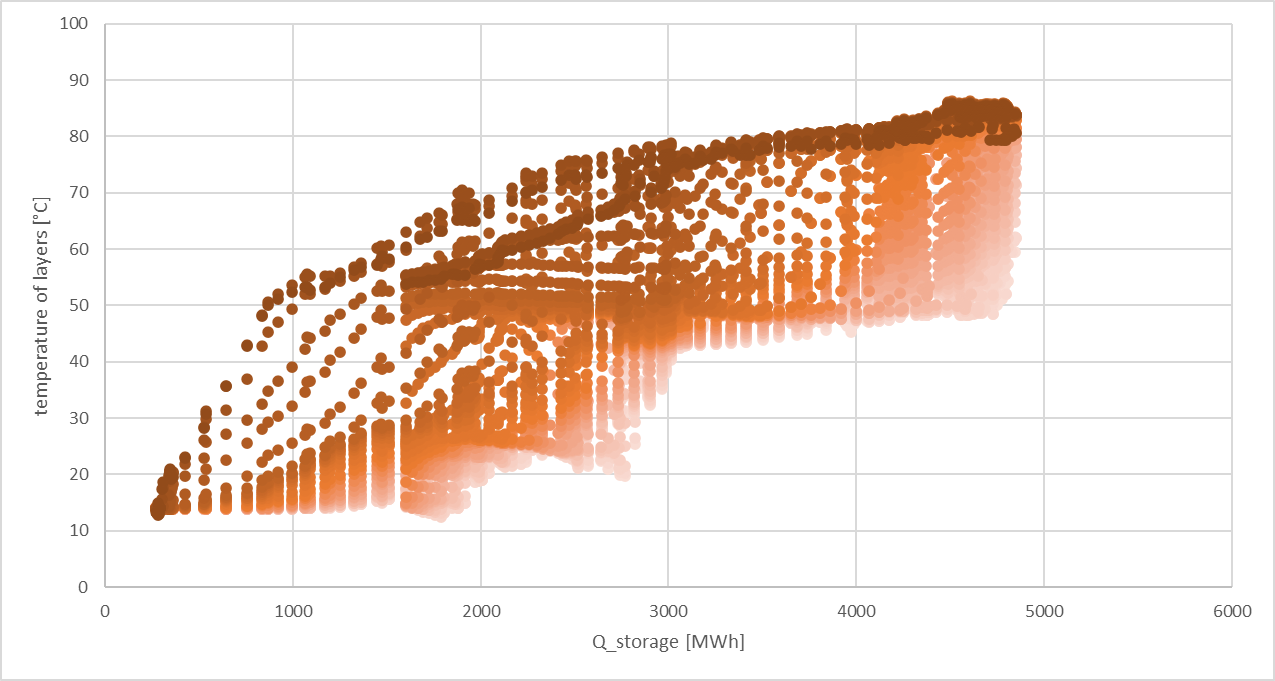

Next a parametrized version of the "temperature map" above is implemented:

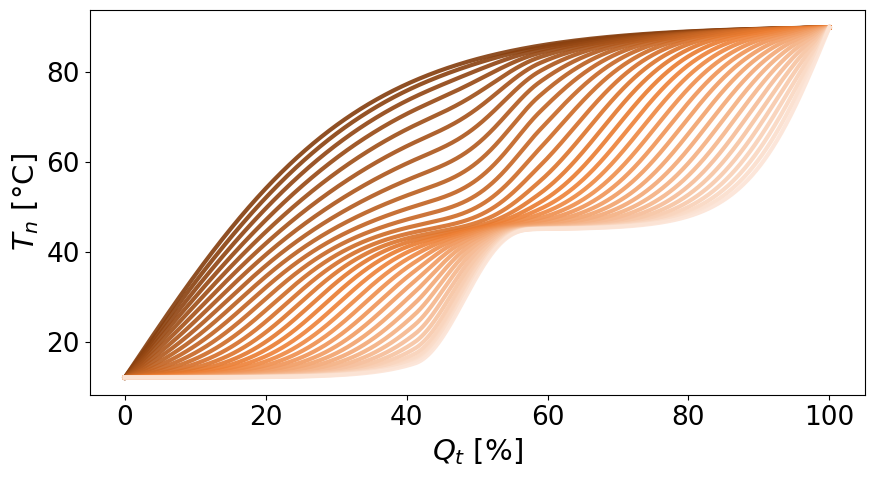

In [50]:
def temperature_map_simple(
    n_layers=32,    # number of storage layers = number of temperature sensors
    T_min=12,       # minimum (cold) storage temperature [°C]
    T_max=90,       # maximum (hot)  storage temperature [°C]
    n_points=2000,  # number of points along the charging-state axis
    stretch=1,      # controls how spread-out the curves are across layers
    sharpness=20,   # steepness of each sigmoid; higher = sharper transition
    plot=False      # if True, display the generated curves
    ):
    """
    Generate a set of synthetic layered temperature maps using shifted
    sigmoids, one curve per storage layer.

    Each curve represents how the temperature of a given layer evolves
    as the storage charges from empty (Q=0 %) to full (Q=100 %).  The
    curves are spread apart by shifting the inflection point of the
    sigmoid across layers, so upper (hotter) layers heat up earlier and
    lower (colder) layers heat up later.

    Parameters
    ----------
    n_layers   : int    Number of layers (= rows in output).
    T_min      : float  Temperature at Q=0 % [°C].
    T_max      : float  Temperature at Q=100 % [°C].
    n_points   : int    Resolution along the charging-state axis (= columns).
    stretch    : float  Total spread of inflection-point shifts across layers.
                        Larger values make curves more distinct from each other.
    sharpness  : float  Sigmoid steepness; higher values give a sharper step.
    plot       : bool   Whether to display the curves after generation.

    Returns
    -------
    curves : np.ndarray, shape (n_layers, n_points)
        Temperature [°C] per layer at each charging state.
        Row 0 = top/hottest layer, row n_layers-1 = bottom/coldest layer.
    """

    # Charging-state axis: 0 (empty) → 1 (full)
    x = np.linspace(0, 1, n_points)

    # Each layer gets a different inflection point, spread symmetrically
    # around 0.5 (the midpoint of the charging axis)
    shifts = np.linspace(-0.5 * stretch, 0.5 * stretch, n_layers)

    curves = []
    for s in shifts:
        # Sigmoid shifted by s; larger s → curve bends earlier (higher layer)
        y = 1 / (1 + np.exp(-sharpness * (x - 0.5 + s)))

        # Normalize each curve individually so it spans exactly [0, 1],
        # removing the flat tails that sigmoids never actually reach
        y = (y - y.min()) / (y.max() - y.min())
        curves.append(y)

    # Scale from [0, 1] to [T_min, T_max]
    curves = np.array(curves) * (T_max - T_min) + T_min

    # Flip row order so index 0 is the hottest (top) layer
    curves = np.flip(curves, axis=0)

    # --- Optional plot ---
    if plot:
        plt.rcParams.update({'font.size': 19})
        plt.figure(figsize=(10, 5))

        # Brown-to-cream gradient: dark = hot (top), light = cold (bottom)
        cmap = mcolors.LinearSegmentedColormap.from_list(
            "custom_brown", ["#833C0C", "#ED7D31", "#FCE4D6"]
        )

        for i in range(n_layers):
            plt.plot(x * 100, curves[i], color=cmap(i / (n_layers - 1)), linewidth=3, alpha=1.0)

        plt.xlabel(r"$Q_t$ [%]", fontsize=21)
        plt.ylabel(r"$T_n$ [°C]", fontsize=21)
        plt.show()
        plt.rcParams.update({'font.size': 10})

    return np.array(curves)


def temperature_map(
    n_layers=32,
    T_min=12,
    T_mid=45,       # intermediate temperature; set to None for a single-stage map
    T_max=90,
    n_points=2000,
    stretch=1,
    sharpness=10,
    overlap=0.3,    # fraction [0, 1] of the two stages that overlap in charging state
    plot=False
    ):
    """
    Generate a synthetic temperature map for a storage with an optional
    two-stage charging profile (e.g. direct solar charging up to T_mid,
    then heat-pump assisted charging up to T_max).

    Single-stage mode (T_mid=None)
    --------------------------------
    Delegates directly to temperature_map_simple spanning T_min → T_max.

    Two-stage (cascaded) mode (T_mid is set)
    -----------------------------------------
    Three base curve sets are generated and blended:

      curves_1 : T_min → T_mid  (first charging stage)
      curves_2 : T_mid → T_max  (second charging stage, offset in time)
      curves_3 : T_min → T_max  (softer background used for upper layers
                                  that blend between the two stages)

    Two spatial–temporal masks control the blending:
      mask_1 / mask_2  : time-domain crossfade between stage 1 and stage 2
      mask_3           : layer-domain blend that fades the cascaded result
                         into the smooth background for the top half of layers

    Parameters
    ----------
    n_layers  : int    Number of storage layers.
    T_min     : float  Minimum storage temperature [°C].
    T_mid     : float  Intermediate temperature between the two stages [°C],
                       or None to use a single-stage map.
    T_max     : float  Maximum storage temperature [°C].
    n_points  : int    Number of charging-state points per stage.
    stretch   : float  Layer spread (passed to temperature_map_simple).
    sharpness : float  Sigmoid steepness (passed to temperature_map_simple).
    overlap   : float  Fractional overlap [0, 1] between the two stages.
                       Higher values → smoother transition between stages.
    plot      : bool   Whether to display the final curves.

    Returns
    -------
    T_curves : np.ndarray, shape (n_layers, n_total_points)
        Temperature map [°C].  Row 0 = top layer, last row = bottom layer.
        n_total_points = n_points + shift  where shift = int(n_points*(1-overlap)).
    """

    if T_mid is None:
        # ----------------------------------------------------------------
        # Single-stage fallback: one smooth sigmoid map from T_min to T_max
        # ----------------------------------------------------------------
        T_curves = temperature_map_simple(
            n_layers, T_min, T_max, n_points, stretch, sharpness, False
        )

    else:
        # ----------------------------------------------------------------
        # Two-stage cascaded map
        # ----------------------------------------------------------------

        # shift = number of columns by which stage 2 is delayed relative
        # to stage 1.  A larger overlap shrinks the delay (more simultaneous).
        shift = int(n_points * (1 - overlap))

        # --- Base curve sets ---
        # Stage 1: storage charges from T_min to T_mid
        curves_1 = temperature_map_simple(n_layers, T_min, T_mid,       n_points,         stretch, sharpness,     False)
        # Stage 2: storage charges from 0 to (T_max - T_mid); T_mid offset added later
        curves_2 = temperature_map_simple(n_layers, 0,     T_max - T_mid, n_points,        stretch, sharpness,     False)
        # Background: smooth single-stage map at lower sharpness, used for top layers
        curves_3 = temperature_map_simple(n_layers, T_min, T_max,       n_points + shift,  stretch, sharpness - 4, False)

        # --- Extend curves_1 and curves_2 to the full time axis ---
        # curves_1 holds its final value (≈ T_mid) during the stage-2 delay period
        shift_T_mid = np.column_stack([curves_1[:, -1]] * shift)
        curves_1    = np.hstack((curves_1, shift_T_mid))

        # curves_2 stays at T_mid (zero offset columns) during stage 1,
        # then adds the T_mid baseline so it starts exactly at T_mid
        shift_zeros = np.zeros((n_layers, shift))
        curves_2    = np.hstack((shift_zeros, curves_2))
        curves_2   += T_mid

        # --- Time-domain crossfade masks (mask_1, mask_2) ---
        # Sinusoidal transition from stage 1 → stage 2 over the non-overlapping window
        transition_1 = np.linspace(-np.pi / 2, np.pi / 2, n_points - shift)
        transition_1 = (np.sin(transition_1) + 1) / 2          # smooth 0→1 ramp

        # mask_1: 1 during stage 1, fades to 0 at the end
        mask_1 = np.hstack((np.ones(shift), 1 - transition_1, np.zeros(shift)))
        # mask_2: 0 during stage 1, fades to 1 at the end
        mask_2 = np.hstack((np.zeros(shift), transition_1,     np.ones(shift)))

        # --- Layer-domain blend mask (mask_3) ---
        # The top half of layers blend into the smoother background (curves_3),
        # while the bottom half use the fully cascaded result.
        shift_transition_2 = int(n_layers / 2)
        transition_2 = np.linspace(-np.pi / 2, np.pi / 2, shift_transition_2)
        transition_2 = (np.sin(transition_2) + 1) / 2          # smooth 0→1 ramp

        # Pad with zeros for the bottom half (no blending there)
        transition_2 = np.hstack((np.zeros(n_layers - shift_transition_2), transition_2))
        transition_2 = np.flip(transition_2)  # index 0 (top) gets weight 1 → curves_3

        # Broadcast the per-layer weights across all time columns
        mask_3 = np.column_stack([transition_2.T] * len(mask_1))

        # --- Blend: cascaded stages + background ---
        T_curves = (curves_1 * mask_1 + curves_2 * mask_2) * (1 - mask_3) + curves_3 * mask_3

    # --- Optional plot ---
    if plot:
        plt.rcParams.update({'font.size': 19})

        cmap = mcolors.LinearSegmentedColormap.from_list(
            "custom_brown", ["#833C0C", "#ED7D31", "#FCE4D6"]
        )

        plt.figure(figsize=(10, 5))
        for i in range(n_layers):
            x = np.linspace(0, 1, T_curves.shape[1]) * 100
            plt.plot(x, T_curves[i], color=cmap(i / (n_layers - 1)), linewidth=3, alpha=0.9)

        plt.xlabel(r"$Q_t$ [%]", fontsize=21)
        plt.ylabel(r"$T_n$ [°C]", fontsize=21)
        plt.show()
        plt.rcParams.update({'font.size': 10})

    return T_curves

temperature_map(32, 12, 45, 90, 2000, 1, 10, 0.3, True)

dronninglund_PTES.set_temperature_map(temperature_map(32, 12, 45, 90, 2000, 1, 10, 0.3, False))

With the data from 2014, the heat transfer coefficients k for the lid, side and bottom are calibrated (The function for this calculation are stored in the PTES class). It is an optimization based calculation which uses the shares of heat lost through the lid, side walls and bottom, respectively as well as the total heat loss of the calibration period:

In [51]:
data_dronninglund = data_import("dronninglund_data_2014.xlsx")
Q_storage_2014_dronninglund = data_dronninglund['Q_storage'].to_numpy()
Q_storage_2014_dronninglund = Q_storage_2014_dronninglund[30:]
Q_storage_start_2014_dronninglund = Q_storage_2014_dronninglund[0]
Q_storage_end_2014_dronninglund = Q_storage_2014_dronninglund[-1]

dronninglund_PTES.calculate_U_values_PTES(file_path, Q_storage_start_2014_dronninglund, Q_storage_end_2014_dronninglund, 0.56, 0.42, 0.02, 30, None)

print("The calculated heat transfer coefficients are:", dronninglund_PTES.U_lid, dronninglund_PTES.U_side, dronninglund_PTES.U_bottom)

The calculated heat transfer coefficients are: 0.16222538853188978 0.16418066462925487 0.20031920744591564


The next step is to simulate the energy content of the pit storage from 2014 to 2017 for that the simulation of the year 2014 is extended. The heat in and out of the storage for 2015 to 2017 is only known on a monthly basis, that's why the data from  2014 is taken and each month is rescaled with a factor to match the heat in and out of the storage in each month:

Loss simulation deviation 2014 0.47693637944692147 % actual loss 2014: 1175
Loss simulation deviation 2015 -3.0358347745289693 % actual loss 2015: 1275
Loss simulation deviation 2016 7.276764279144196 % actual loss 2016: 1046
Loss simulation deviation 2017 136.42534168083782 % actual loss 2017: 388
U-values used for dronninglund: 0.16222538853188978 (lid) 0.16418066462925487 (side) 0.20031920744591564 (bottom)
A_lid: 8281 A_side: 8476.647981366219 A_bottom: 676 V_storage: 60389.33333333333


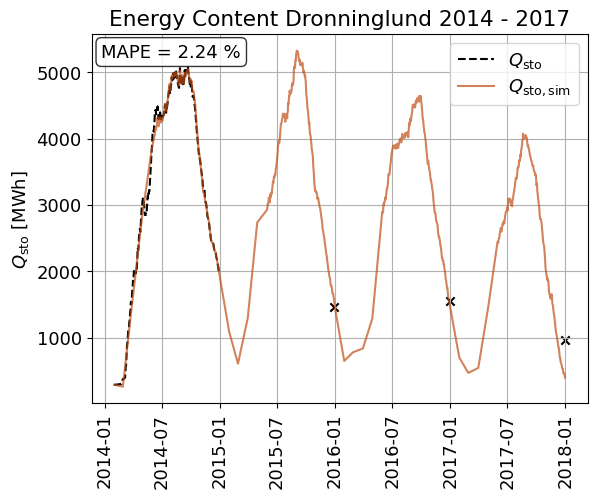

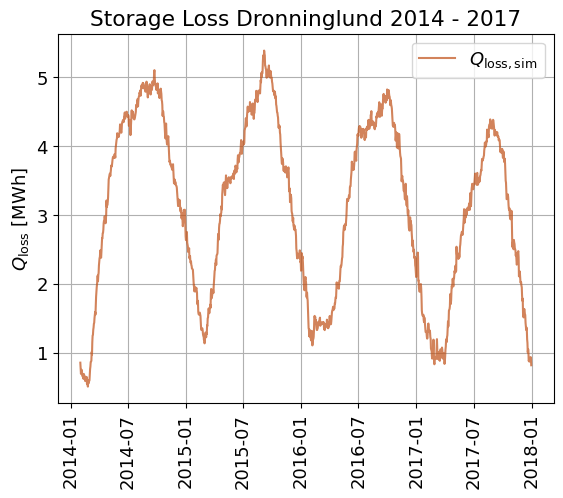

In [52]:
# energy losses in MWh for the years 2014-2017 from (https://www.solar-district-heating.eu/wp-content/uploads/2019/10/Dronninglund-evaluation-report-2015-2017_20190531.pdf)
Q_loss_2014=1175
Q_loss_2015=1275
Q_loss_2016=1046
Q_loss_2017=388

# defining the starting point of the simulation for 2014
data_dronninglund = data_import("dronninglund_data_2014.xlsx")
Q_storage_2014_dronninglund = data_dronninglund['Q_storage'].to_numpy()
Q_storage_2014_dronninglund = Q_storage_2014_dronninglund[30:]
Q_storage_start_2014_dronninglund = Q_storage_2014_dronninglund[0] # initial storage energy content for the year 2014, based on the Dronninglund data

# simulate heat loss and storage energy content for 2014 based on the calculated heat transfer coefficients and the temperature maps.
time_2014_dronninglund, Q_storage_sim_2014_dronninglund, Q_loss_sim_2014_dronninglund, _ = dronninglund_PTES.simulate_PTES("dronninglund_data_2014.xlsx", Q_storage_start=Q_storage_start_2014_dronninglund, sim_start=30)

# data_dronninglund = data_import("dronninglund_data_2015_to_2017.xlsx")

# defining the starting point of the simulation for 2015-2017 based on the simulated storage energy content at the end of 2014, which is used as the initial storage energy content for the year 2015.
Q_storage_start_2015_to_2017_dronninglund = Q_storage_sim_2014_dronninglund[-1]

# simulate heat loss and storage energy content for 2015-2017 based on the calculated heat transfer coefficients and the temperature maps.
time_2015_to_2017_dronninglund, Q_storage_sim_2015_to_2017_dronninglund, Q_loss_sim_2015_to_2017_dronninglund, _ = dronninglund_PTES.simulate_PTES("dronninglund_data_2015_to_2017.xlsx", Q_storage_start=Q_storage_start_2015_to_2017_dronninglund)

# compare the simulated heat loss for each year with the reported heat loss for each year
print("Loss simulation deviation 2014", (np.nansum(Q_loss_sim_2014_dronninglund)-Q_loss_2014)/Q_loss_2014*100, r"% actual loss 2014:", Q_loss_2014)
print("Loss simulation deviation 2015", (np.nansum(Q_loss_sim_2015_to_2017_dronninglund[0:365])-Q_loss_2015)/Q_loss_2015*100, r"% actual loss 2015:", Q_loss_2015)
print("Loss simulation deviation 2016", (np.nansum(Q_loss_sim_2015_to_2017_dronninglund[365:365*2])-Q_loss_2016)/Q_loss_2016*100, r"% actual loss 2016:", Q_loss_2016)
print("Loss simulation deviation 2017", (np.nansum(Q_loss_sim_2015_to_2017_dronninglund[365*2:365*3])-Q_loss_2017)/Q_loss_2017*100, r"% actual loss 2017:", Q_loss_2017)
print("U-values used for dronninglund:", dronninglund_PTES.U_lid, "(lid)", dronninglund_PTES.U_side, "(side)", dronninglund_PTES.U_bottom, "(bottom)")
print("A_lid:", dronninglund_PTES.A_top, "A_side:", dronninglund_PTES.A_side, "A_bottom:", dronninglund_PTES.A_bottom, "V_storage:", dronninglund_PTES.V_storage)

# concatenate the simulated storage energy content for the years 2014-2017 and the corresponding time arrays for plotting
Q_storage_sim_2014_to_2017_dronninglund = np.concatenate((Q_storage_sim_2014_dronninglund, Q_storage_sim_2015_to_2017_dronninglund))
Q_loss_sim_2014_to_2017_dronninglund = np.concatenate((Q_loss_sim_2014_dronninglund, Q_loss_sim_2015_to_2017_dronninglund))
time_2014_to_2017_dronninglund = np.concatenate((time_2014_dronninglund, time_2015_to_2017_dronninglund))

# the difference of internal energy of the storage between the end and the beginning of each year is given (https://www.solar-district-heating.eu/wp-content/uploads/2019/10/Dronninglund-evaluation-report-2015-2017_20190531.pdf)
Q_storage_end_2014_dronninglund = 1663 + Q_storage_start_2014_dronninglund
Q_storage_end_2015_dronninglund = Q_storage_end_2014_dronninglund - 497
Q_storage_end_2016_dronninglund = Q_storage_end_2015_dronninglund + 93
Q_storage_end_2017_dronninglund = Q_storage_end_2016_dronninglund - 583

# calculate the mean absolute error (MAE) between the simulated and reported storage energy content for 2014, normalized by the mean of the reported storage energy content for 2014, and expressed as a percentage.
mae_2014 = mean_absolute_error(Q_storage_2014_dronninglund,Q_storage_sim_2014_dronninglund) / np.nanmean(Q_storage_2014_dronninglund) * 100

plt.rcParams.update({'font.size': 13})

plt.plot(time_2014_dronninglund, Q_storage_2014_dronninglund, label=r"$Q_{\mathrm{sto}}$", color="black", linestyle="dashed")
plt.scatter([time_2014_to_2017_dronninglund[699],time_2014_to_2017_dronninglund[1065],time_2014_to_2017_dronninglund[1430]], [Q_storage_end_2015_dronninglund,Q_storage_end_2016_dronninglund,Q_storage_end_2017_dronninglund], color="black", marker="x", label="_nolegend_")
plt.plot(time_2014_to_2017_dronninglund, Q_storage_sim_2014_to_2017_dronninglund, label=r"$Q_{\mathrm{sto,sim}}$", color="#C04F15", alpha=0.7)
plt.text(0.02, 0.975, f"MAPE = {mae_2014:.2f} %", transform=plt.gca().transAxes, fontsize=13, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xticks(rotation=90)
plt.title("Energy Content Dronninglund 2014 - 2017")
plt.ylabel(r"$Q_{\mathrm{sto}}$ [MWh]")
plt.legend(loc="upper right", labelspacing=0.4)
plt.grid()
# plt.savefig(r"C:\Users\mbkka\Documents\ETHZ\semester_projekt\03_report\dronninglund_energy_content_2014_2017.png", dpi=1000, bbox_inches='tight')
plt.show()

plt.plot(time_2014_to_2017_dronninglund, Q_loss_sim_2014_to_2017_dronninglund, label=r"$Q_{\mathrm{loss,sim}}$", color="#C04F15", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Storage Loss Dronninglund 2014 - 2017")
plt.ylabel(r"$Q_{\mathrm{loss}}$ [MWh]")
plt.legend(loc="upper right", labelspacing=0.4)
plt.grid()
# plt.savefig(r"C:\Users\mbkka\Documents\ETHZ\semester_projekt\03_report\dronninglund_loss_2014_2017.png", dpi=1000, bbox_inches='tight')
plt.show()

Now the simple storage model is fitted to the energy content curve of the storage. This is also done by the ".simulate_PTES()" function provided in the PTES class.

$$Q_{\mathrm{sto,t+1}}=\eta_{\mathrm{self}} \cdot Q_{\mathrm{sto,t}}+\left(\eta_{\mathrm{ch}} \cdot \dot{Q}_{\mathrm{ch}} -\frac{\dot{Q}_{\mathrm{disch}}}{\eta_{\mathrm{disch}}}\right) \cdot \Delta t$$

In this case the charging and discharging efficiencies are 1 because the given $\dot{Q}_{\mathrm{ch}}$ and $\dot{Q}_{\mathrm{disch}}$ are at the inlet of the pit. There is no heat exchanger. The heat is directly transfered with a water flow.

Optimal eta: 0.11707734658628653 % energy loss per day
hourly eta: 0.004880961529352135 % energy loss per hour


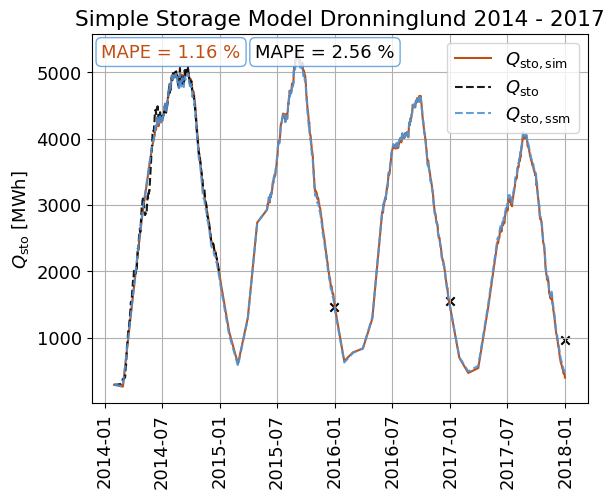

In [53]:
data_dronninglund = data_import("dronninglund_data_2014_to_2017.xlsx")
Q_storage_2014_to_2017_dronninglund = data_dronninglund['Q_storage'].to_numpy()
Q_storage_2014_to_2017_dronninglund = Q_storage_2014_to_2017_dronninglund[30:]
Q_storage_start_2014_to_2017 = Q_storage_2014_to_2017_dronninglund[0]

time_2014_to_2017_dronninglund, Q_storage_sim_2014_to_2017_dronninglund, _, Q_storage_simple_2014_to_2017_dronninglund = dronninglund_PTES.simulate_PTES("dronninglund_data_2014_to_2017.xlsx", Q_storage_start_2014_to_2017, 30)
eta_self_discharge_2014_to_2017_dronninglund = dronninglund_PTES.eta_self_discharge
eta_self_discharge_2014_to_2017_dronninglund_hour = 1-(1-eta_self_discharge_2014_to_2017_dronninglund)**(1/24)

mae_simple_sim = mean_absolute_error(Q_storage_sim_2014_to_2017_dronninglund,Q_storage_simple_2014_to_2017_dronninglund) / np.nanmean(Q_storage_sim_2014_to_2017_dronninglund) * 100
mae_simple_real = mean_absolute_error(Q_storage_2014_to_2017_dronninglund[:335],Q_storage_simple_2014_to_2017_dronninglund[:335]) / np.nanmean(Q_storage_2014_to_2017_dronninglund[:335]) * 100

print("Optimal eta:", eta_self_discharge_2014_to_2017_dronninglund*100, r"% energy loss per day")
print("hourly eta:", eta_self_discharge_2014_to_2017_dronninglund_hour*100, r"% energy loss per hour")

plt.rcParams.update({'font.size': 13})

# plt.plot(time_2014, Q_storage_2014, label="$Q_{\mathrm{sto}}$", color="black", linestyle="dashed")
plt.plot(time_2014_to_2017_dronninglund, Q_storage_sim_2014_to_2017_dronninglund, label=r"$Q_{\mathrm{sto,sim}}$", color="#C04F15", alpha=1.0)
plt.plot(time_2014_to_2017_dronninglund, Q_storage_2014_to_2017_dronninglund, label=r"$Q_{\mathrm{sto}}$", color="#000000", linestyle="dashed", alpha=0.9)
plt.scatter([time_2014_to_2017_dronninglund[699],time_2014_to_2017_dronninglund[1065],time_2014_to_2017_dronninglund[1430]], [Q_storage_end_2015_dronninglund,Q_storage_end_2016_dronninglund,Q_storage_end_2017_dronninglund], color="black", marker="x", label="_nolegend_")
plt.plot(time_2014_to_2017_dronninglund, Q_storage_simple_2014_to_2017_dronninglund, label=r"$Q_{\mathrm{sto,ssm}}$", color="#4E95D9", linestyle="dashed", alpha=0.9)
plt.text(0.02, 0.975, f"MAPE = {mae_simple_sim:.2f} %", transform=plt.gca().transAxes, fontsize=13, verticalalignment='top', color='#C04F15', bbox=dict(boxstyle='round', facecolor='white', edgecolor='#4E95D9', alpha=0.8))
plt.text(0.33, 0.975, f"MAPE = {mae_simple_real:.2f} %", transform=plt.gca().transAxes, fontsize=13, verticalalignment='top', color="#000000", bbox=dict(boxstyle='round', facecolor='white', edgecolor='#4E95D9', alpha=0.8))

plt.xticks(rotation=90)
plt.title("Simple Storage Model Dronninglund 2014 - 2017")
plt.ylabel(r"$Q_{\mathrm{sto}}$ [MWh]")
plt.legend(loc="upper right", labelspacing=0.4)
plt.grid()
# plt.savefig(r"C:\Users\mbkka\Documents\ETHZ\semester_projekt\03_report\dronninglund_energy_content_simple_2014_2017.png", dpi=1000, bbox_inches='tight')
plt.show()

U-values used for hoje taastrup: 0.15374132330637316 (lid) 0.4593977661055154 (side) 0.7815576160160738 (bottom)
A_lid: 11098 A_side: 11425.707175981957 A_bottom: 861 V_storage: 71196.82083333333
Loss simulation deviation 2024 -0.20228739765745354 % actual loss 2014: 1175


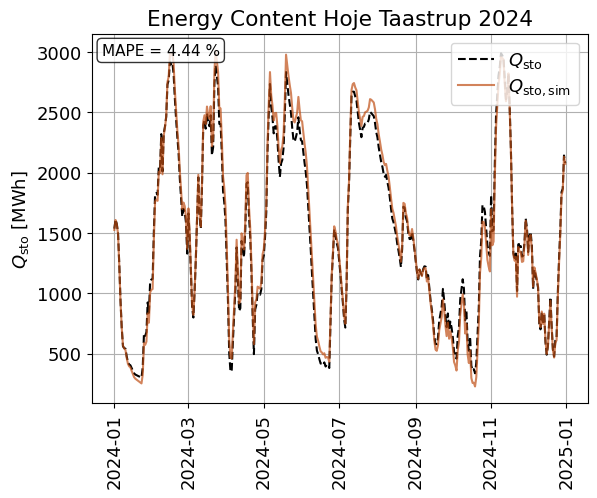

In [54]:
# Extracting data from the DataFrame
data_hoje_taastrup = data_import("hoje_taastrup_data_2024.xlsx")
Q_storage_2024_hoje_taastrup = data_hoje_taastrup['Q_storage'].to_numpy()
Q_storage_start_2024_hoje_taastrup = Q_storage_2024_hoje_taastrup[0]
Q_storage_end_2024_hoje_taastrup = Q_storage_2024_hoje_taastrup[-1]
Q_loss_2024 = 3598

first_T_hoje_taastrup = data_hoje_taastrup.columns.get_loc('T_01')
T_storage_hoje_taastrup = data_hoje_taastrup.iloc[:, first_T:].to_numpy()

# Extracting geometry parameters
n_layers_hoje_taastrup = T_storage_hoje_taastrup.shape[1] # Number of layers corresponds to the number of temperature sensors in the storage
hoje_taastrup_PTES = PTES(*PTES_geometry_import("hoje_taastrup_data_2024.xlsx"), n_layers_hoje_taastrup, T_min=48.5, T_max=90, T_ref=48.5)
share_loss_lid = 0.31
share_loss_side = 11/12*0.69
share_loss_bottom = 1/12*0.69
hoje_taastrup_PTES.set_temperature_map(temperature_map_simple(n_layers_hoje_taastrup, 48.5, 90, 2000, 1, 15, False))
hoje_taastrup_PTES.calculate_U_values_PTES('hoje_taastrup_data_2024.xlsx', Q_storage_start_2024_hoje_taastrup, Q_storage_end_2024_hoje_taastrup, share_loss_lid, share_loss_side, share_loss_bottom)
time_2024_hoje_taastrup, Q_storage_sim_2024_hoje_taastrup, Q_loss_sim_2024_hoje_taastrup, _ = hoje_taastrup_PTES.simulate_PTES("hoje_taastrup_data_2024.xlsx", Q_storage_start=Q_storage_start_2024_hoje_taastrup)

# calculate the mean absolute error (MAE) between the simulated and reported storage energy content for 2014, normalized by the mean of the reported storage energy content for 2014, and expressed as a percentage.
mae_2024 = mean_absolute_error(Q_storage_2024_hoje_taastrup,Q_storage_sim_2024_hoje_taastrup) / np.nanmean(Q_storage_2024_hoje_taastrup) * 100

Q_storage_end_2024_hoje_taastrup = Q_storage_sim_2024_hoje_taastrup[-1]

# print("U-values used for dronninglund:", dronninglund_PTES.U_lid, "(lid)", dronninglund_PTES.U_side, "(side)", dronninglund_PTES.U_bottom, "(bottom)")
print("U-values used for hoje taastrup:", hoje_taastrup_PTES.U_lid, "(lid)", hoje_taastrup_PTES.U_side, "(side)", hoje_taastrup_PTES.U_bottom, "(bottom)")
print("A_lid:", hoje_taastrup_PTES.A_top, "A_side:", hoje_taastrup_PTES.A_side, "A_bottom:", hoje_taastrup_PTES.A_bottom, "V_storage:", hoje_taastrup_PTES.V_storage)
print("Loss simulation deviation 2024", (np.nansum(Q_loss_sim_2024_hoje_taastrup)-Q_loss_2024)/Q_loss_2024*100, r"% actual loss 2014:", Q_loss_2014)

plt.rcParams.update({'font.size': 13})

plt.plot(time_2024_hoje_taastrup, Q_storage_2024_hoje_taastrup, label=r"$Q_{\mathrm{sto}}$", color="black", linestyle="dashed")
# plt.scatter([time_2024_hoje_taastrup[365]], [Q_storage_end_2024_hoje_taastrup], color="black", marker="x", label="$Q_{storage, yearly}$")
plt.plot(time_2024_hoje_taastrup, Q_storage_sim_2024_hoje_taastrup, label=r"$Q_{\mathrm{sto,sim}}$", color="#C04F15", alpha=0.7)
plt.text(0.02, 0.975, f"MAPE = {mae_2024:.2f} %", transform=plt.gca().transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xticks(rotation=90)
plt.title("Energy Content Hoje Taastrup 2024")
plt.ylabel(r"$Q_{\mathrm{sto}}$ [MWh]")
plt.legend(loc="upper right", labelspacing=0.4)
plt.grid()
# plt.savefig(r"C:\Users\mbkka\Documents\ETHZ\semester_projekt\03_report\hoje_taastrup_energy_content_2024.png", dpi=1000, bbox_inches='tight')

plt.show()

U-values used for marstal: 0.2685415730417418 (lid) 0.3130395059171851 (side) 0.47656913608582563 (bottom)
A_lid: 9941.49 A_side: 9899.118929986895 A_bottom: 1075.76 V_storage: 77691.42000000001


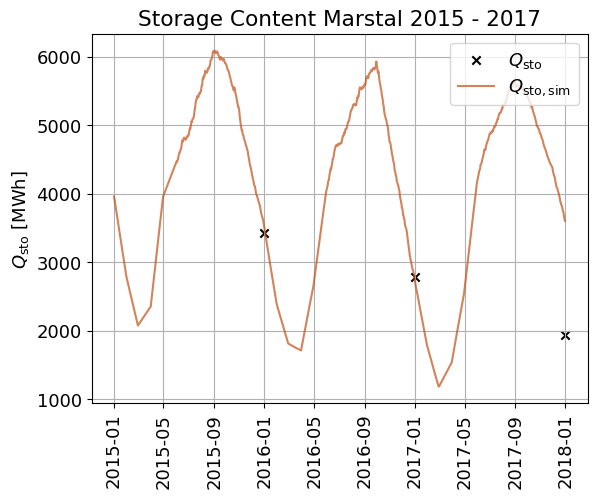

In [55]:
Q_storage_start_2015_marstal = 4000 # MWh
Q_storage_end_2015_marstal = 3431 # MWh
Q_storage_end_2016_marstal = 2789 # MWh
Q_storage_end_2017_marstal = 1931 # MWh

# Extracting geometry parameters
n_layers_marstal = 32 # Number of layers corresponds to the number of temperature sensors in the storage
marstal_PTES = PTES(*PTES_geometry_import("marstal_data_2015_to_2017.xlsx"), n_layers_marstal, T_min=10, T_max=86, T_ref=10)
marstal_PTES.set_temperature_map(temperature_map(n_layers_marstal, 10, 45, 86, 2000, 1, 10, 0.3, False))
marstal_PTES.calculate_U_values_PTES('marstal_data_2015_to_2017.xlsx', Q_storage_start_2015_marstal, Q_storage_end_2016_marstal, 0.56, 0.41, 0.03, None, 730)
time_2015_to_2017_marstal, Q_storage_sim_2015_to_2017_marstal, _, _ = marstal_PTES.simulate_PTES("marstal_data_2015_to_2017.xlsx", Q_storage_start=Q_storage_start_2015_marstal)

# print("U-values used for dronninglund:", dronninglund_PTES.U_lid, "(lid)", dronninglund_PTES.U_side, "(side)", dronninglund_PTES.U_bottom, "(bottom)")
# print("U-values used for hoje taastrup:", hoje_taastrup_PTES.U_lid, "(lid)", hoje_taastrup_PTES.U_side, "(side)", hoje_taastrup_PTES.U_bottom, "(bottom)")
print("U-values used for marstal:", marstal_PTES.U_lid, "(lid)", marstal_PTES.U_side, "(side)", marstal_PTES.U_bottom, "(bottom)")
print("A_lid:", marstal_PTES.A_top, "A_side:", marstal_PTES.A_side, "A_bottom:", marstal_PTES.A_bottom, "V_storage:", marstal_PTES.V_storage)

plt.rcParams.update({'font.size': 13})

plt.scatter([time_2015_to_2017_marstal[364], time_2015_to_2017_marstal[730], time_2015_to_2017_marstal[1095]], [Q_storage_end_2015_marstal, Q_storage_end_2016_marstal, Q_storage_end_2017_marstal], color="black", marker="x", label=r"$Q_{\mathrm{sto}}$")
plt.plot(time_2015_to_2017_marstal, Q_storage_sim_2015_to_2017_marstal, label=r"$Q_{\mathrm{sto,sim}}$", color="#C04F15", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Storage Content Marstal 2015 - 2017")
# plt.xlabel("time")
plt.ylabel(r"$Q_{\mathrm{sto}}$ [MWh]")
plt.legend(loc="upper right", labelspacing=0.4)
plt.grid()

plt.show()

The next step is to determine generally valid U-values. An optimization-based approach is used to calculate the U-values, that match best to simulate the energy content of two pit storages (Dronninglund & Høje Taastrup).


U = [0.305, 0.267, 0.216] | MAPE_dron = 11.627% | MAPE_hoje = 4.232% | MAPE_sum = 15.859 | balance_pen = 0.000 | fit = 15.858803 | reg = 0.798975 | total = 16.258291

OPTIMAL GLOBAL U-values
U_lid    = 0.304840
U_side   = 0.266712
U_bottom = 0.216057


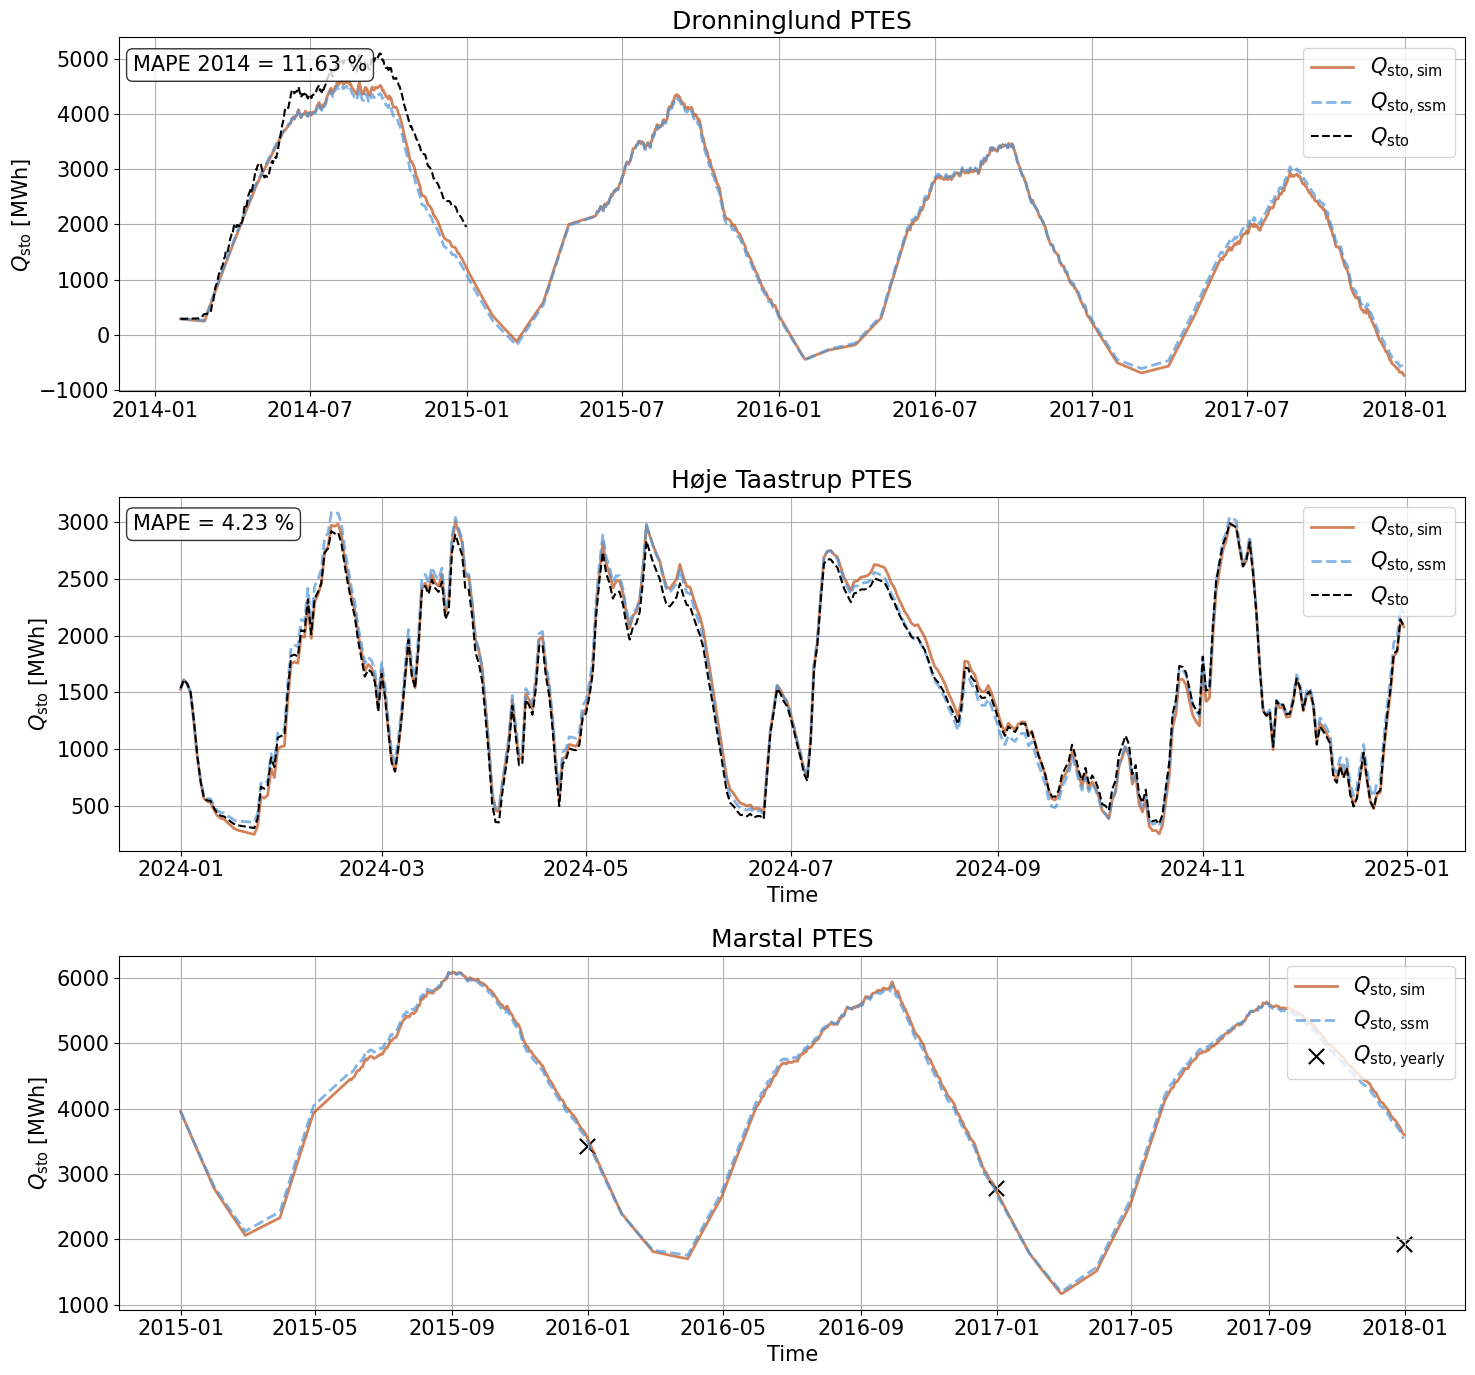

In [ ]:
# Global Optimization of PTES U-values Across Multiple Storages

# =============================================================
# TARGET VALUES
# =============================================================

# -----------------------------
# Dronninglund
# -----------------------------

# Daily target array for 2014 (335 values, aligned with sim_start=30)
# Q_storage_2014_dronninglund is assumed to already exist

# -----------------------------
# Høje Taastrup
# -----------------------------

# Daily target array for 2024
# Q_storage_2024_hoje_taastrup is assumed to already exist

# -----------------------------
# Marstal
# -----------------------------

Q_targets_marstal = {
    2015: Q_storage_end_2015_marstal,
    2016: Q_storage_end_2016_marstal,
    2017: Q_storage_end_2017_marstal,
}


# =============================================================
# HELPER FUNCTIONS
# =============================================================


def calculate_yearly_error(time, Q_storage_sim, targets):
    """
    Calculates squared relative error at the end of each year.
    """

    error = 0

    years = np.array(time.year)

    for year, Q_target in targets.items():

        idx = np.where(years == year)[0]

        if len(idx) == 0:
            continue

        # Last timestep of the year
        year_end_idx = idx[-1]

        Q_sim = Q_storage_sim[year_end_idx]

        rel_error = (Q_sim - Q_target) / Q_target

        error += rel_error**2

    return error


def calculate_MAPE(time, Q_storage_sim, year, Q_target_array):
    """
    Calculates the normalized mean absolute error (MAPE, in %) over
    daily data for a given year. Matches the MAE% metric used in the
    plots: mean(|sim - target|) / mean(target) * 100.

    Assumes Q_target_array aligns directly with the simulated values
    for `year` (i.e. Q_target_array[0] corresponds to the first
    simulated timestep of `year`, with no offset).

    Parameters
    ----------
    time : pandas DatetimeIndex (or similar, with a .year attribute)
        Simulation time vector.
    Q_storage_sim : array-like
        Simulated storage content, same length as `time`.
    year : int
        Year to compare against.
    Q_target_array : array-like
        Daily target values for `year`.

    Returns
    -------
    mape : float
        Normalized mean absolute error, in percent. Directly
        comparable across sites regardless of number of data points
        or absolute storage size.
    """

    Q_target_array = np.asarray(Q_target_array)

    years = np.array(time.year)

    year_start_idx = np.where(years == year)[0][0]

    Q_sim_year = np.asarray(Q_storage_sim)[year_start_idx: year_start_idx + len(Q_target_array)]

    mape = np.mean(np.abs(Q_sim_year - Q_target_array)) / np.nanmean(Q_target_array) * 100

    return mape


# =============================================================
# OBJECTIVE FUNCTION
# =============================================================


def objective_global_U_values(U_values):
    """
    Objective function mapping loss coefficients [Lid, Side, Bottom] to a 
    regularized, multi-site simulation tracking error score.
    """

    U_lid, U_side, U_bottom = U_values

    # =========================================================
    # PRIOR VALUES
    # =========================================================

    k_prior = np.array([
        0.167,   # lid
        0.200,   # side
        0.200    # bottom
    ])

    # =========================================================
    # APPLY U-values
    # =========================================================

    for storage in [
        dronninglund_PTES,
        hoje_taastrup_PTES,
    ]:

        storage.U_lid = U_lid
        storage.U_side = U_side
        storage.U_bottom = U_bottom

    # =========================================================
    # SIMULATIONS
    # =========================================================

    time_dronninglund, Q_storage_dronninglund, _, _ = dronninglund_PTES.simulate_PTES("dronninglund_data_2014_to_2017.xlsx", Q_storage_start=Q_storage_start_2014_dronninglund, sim_start=30)

    time_hoje_taastrup, Q_storage_hoje_taastrup, _, _ = hoje_taastrup_PTES.simulate_PTES("hoje_taastrup_data_2024.xlsx", Q_storage_start=Q_storage_start_2024_hoje_taastrup)

    # Marstal is not included in the fit (see below), so it is not
    # simulated here to save time during optimization.

    # =========================================================
    # FIT ERRORS
    # =========================================================

    # Dronninglund: MAPE over 2014
    mape_dronninglund = calculate_MAPE(
        time_dronninglund, Q_storage_dronninglund,
        year=2014, Q_target_array=Q_storage_2014_dronninglund
    )

    # Høje Taastrup: MAPE over the full 2024 series
    mape_hoje_taastrup = calculate_MAPE(
        time_hoje_taastrup, Q_storage_hoje_taastrup,
        year=2024, Q_target_array=Q_storage_2024_hoje_taastrup
    )

    # Both MAPE values are in % and directly comparable across sites.
    # A plain sum alone lets the optimizer trade one site off against
    # the other freely (e.g. 2% + 20% scores the same as 11% + 11%),
    # so we add a penalty on the squared difference between the two
    # to explicitly push them toward balance.

    mape_sum = mape_dronninglund + mape_hoje_taastrup
    mape_diff_penalty = (mape_dronninglund - mape_hoje_taastrup)**2

    # weight_balance controls how strongly balance is prioritized
    # relative to the overall fit. >1 favors closing the gap between
    # sites even if it costs some total MAPE.
    weight_balance = 0.0

    fit_error = mape_sum + weight_balance * mape_diff_penalty

    # =========================================================
    # REGULARIZATION
    # =========================================================

    k_current = np.array([
        U_lid,
        U_side,
        U_bottom
    ])

    regularization_error = np.sum(((k_current - k_prior) / k_prior)**2)

    # =========================================================
    # TOTAL OBJECTIVE
    # =========================================================

    # lambda controls how strongly we trust prior values

    lambda_reg = 0.5

    total_error = (fit_error + lambda_reg * regularization_error)

    clear_output(wait=True)
    print(
        f"U = [{U_lid:.3f}, {U_side:.3f}, {U_bottom:.3f}] | "
        f"MAPE_dron = {mape_dronninglund:.3f}% | "
        f"MAPE_hoje = {mape_hoje_taastrup:.3f}% | "
        f"MAPE_sum = {mape_sum:.3f} | "
        f"balance_pen = {weight_balance * mape_diff_penalty:.3f} | "
        f"fit = {fit_error:.6f} | "
        f"reg = {regularization_error:.6f} | "
        f"total = {total_error:.6f}"
    )

    return total_error


# =============================================================
# INITIAL GUESS
# =============================================================

# Average of previous individually fitted values

k0 = np.array([
    0.167,   # lid
    0.200,   # side
    0.200,   # bottom
])


# =============================================================
# BOUNDS
# =============================================================

bounds = [
    (0.05, 2.0),
    (0.05, 2.0),
    (0.05, 2.0),
]


# =============================================================
# OPTIMIZATION
# =============================================================

result = minimize(objective_global_U_values, x0=k0, bounds=bounds, method='L-BFGS-B')

# =============================================================
# OPTIMAL VALUES
# =============================================================

U_lid_opt, U_side_opt, U_bottom_opt = result.x

print("\n================================================")
print("OPTIMAL GLOBAL U-values")
print("================================================")
print(f"U_lid    = {U_lid_opt:.6f}")
print(f"U_side   = {U_side_opt:.6f}")
print(f"U_bottom = {U_bottom_opt:.6f}")
print("================================================")


# =============================================================
# APPLY OPTIMAL VALUES
# =============================================================

for storage in [
    dronninglund_PTES,
    hoje_taastrup_PTES,
    marstal_PTES,
]:

    storage.U_lid = U_lid_opt
    storage.U_side = U_side_opt
    storage.U_bottom = U_bottom_opt
    # storage.U_lid = k0[0]
    # storage.U_side = k0[1]
    # storage.U_bottom = k0[2]
    # storage.U_lid = 0.15
    # storage.U_side = 0.42
    # storage.U_bottom = 0.42


# =============================================================
# FINAL SIMULATIONS
# =============================================================

time_dronninglund, Q_storage_dronninglund, _, Q_storage_simple_dronninglund = dronninglund_PTES.simulate_PTES("dronninglund_data_2014_to_2017.xlsx", Q_storage_start=Q_storage_start_2014_dronninglund, sim_start=30)

time_hoje_taastrup, Q_storage_hoje_taastrup, _, Q_storage_simple_hoje_taastrup = hoje_taastrup_PTES.simulate_PTES("hoje_taastrup_data_2024.xlsx", Q_storage_start=Q_storage_start_2024_hoje_taastrup)

time_marstal, Q_storage_marstal, _, Q_storage_simple_marstal = marstal_PTES.simulate_PTES("marstal_data_2015_to_2017.xlsx", Q_storage_start=Q_storage_start_2015_marstal)


# =============================================================
# PLOTTING
# =============================================================

plt.rcParams.update({'font.size': 15})
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=False)
# fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

# =========================================================
# DRONNINGLUND
# =========================================================

# Select only 2014 data from the simulated series
mask_2014 = np.array(time_dronninglund.year) == 2014

Q_storage_sim_2014 = np.array(Q_storage_dronninglund)[mask_2014]

# Compute MAE
mae_2014 = mean_absolute_error(Q_storage_2014_dronninglund,Q_storage_sim_2014) / np.nanmean(Q_storage_2014_dronninglund) * 100

ax = axes[0]

ax.plot(time_dronninglund, Q_storage_dronninglund, label=r'$Q_{\mathrm{sto,sim}}$', linewidth=2, color="#C04F15", alpha=0.7)
ax.plot(time_dronninglund, Q_storage_simple_dronninglund, label=r'$Q_{\mathrm{sto,ssm}}$', linewidth=2, color="#4E95D9", linestyle="dashed", alpha=0.7)
ax.plot(time_2014_dronninglund, Q_storage_2014_dronninglund, label=r"$Q_{\mathrm{sto}}$", color="black", linestyle="dashed")
ax.text(0.01, 0.95, f"MAPE 2014 = {mae_2014:.2f} %", transform=ax.transAxes, fontsize=15, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('Dronninglund PTES')
ax.set_ylabel(r'$Q_{\mathrm{sto}}$ [MWh]')
ax.grid(True)
ax.legend(loc="upper right", labelspacing=0.4)


# =========================================================
# HØJE TAASTRUP
# =========================================================

# Compute MAE
mae_2024 = mean_absolute_error(Q_storage_2024_hoje_taastrup,Q_storage_hoje_taastrup) / np.nanmean(Q_storage_2024_hoje_taastrup) * 100

ax = axes[1]

ax.plot(time_hoje_taastrup, Q_storage_hoje_taastrup, label=r'$Q_{\mathrm{sto,sim}}$', linewidth=2, color="#C04F15", alpha=0.7)
ax.plot(time_hoje_taastrup, Q_storage_simple_hoje_taastrup, label=r'$Q_{\mathrm{sto,ssm}}$', linewidth=2, color="#4E95D9", linestyle="dashed", alpha=0.7)
ax.plot(time_2024_hoje_taastrup, Q_storage_2024_hoje_taastrup, label=r"$Q_{\mathrm{sto}}$", color="black", linestyle="dashed")
ax.text(0.01, 0.95, f"MAPE = {mae_2024:.2f} %", transform=ax.transAxes, fontsize=15, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('Høje Taastrup PTES')
ax.set_ylabel(r'$Q_{\mathrm{sto}}$ [MWh]')
ax.set_xlabel('Time')
ax.grid(True)
ax.legend(loc="upper right", labelspacing=0.4)


# =========================================================
# MARSTAL
# =========================================================

ax = axes[2]

ax.plot(time_marstal, Q_storage_marstal, label=r'$Q_{\mathrm{sto,sim}}$', linewidth=2, color="#C04F15", alpha=0.7)
ax.plot(time_marstal, Q_storage_simple_marstal, label=r'$Q_{\mathrm{sto,ssm}}$', linewidth=2, color="#4E95D9", linestyle="dashed", alpha=0.7)

first_marker = True

for year, Q_target in Q_targets_marstal.items():

    idx = np.where(np.array(time_marstal.year) == year)[0]

    if len(idx) == 0:
        continue

    year_end_idx = idx[-1]

    if first_marker:

        ax.scatter(time_marstal[year_end_idx], Q_target, s=120, marker='x', color='black', label=r'$Q_{\mathrm{sto,yearly}}$')

        first_marker = False

    else:

        ax.scatter(time_marstal[year_end_idx], Q_target, s=120, marker='x', color='black')

ax.set_title('Marstal PTES')
ax.set_ylabel(r'$Q_{\mathrm{sto}}$ [MWh]')
ax.set_xlabel('Time')
ax.grid(True)
ax.legend(loc="upper right", labelspacing=0.4)


# =============================================================
# FINALIZE FIGURE
# =============================================================

plt.tight_layout()
# plt.savefig(r"C:\Users\mbkka\Documents\ETHZ\semester_projekt\03_report\combined_U_values.png", dpi=1000, bbox_inches='tight')
plt.show()

In [57]:
print("optimal U_lid:", dronninglund_PTES.U_lid, "optimal U_side:", dronninglund_PTES.U_side, "optimal U_bottom:", dronninglund_PTES.U_bottom)
print("eta_self_discharge for dronninglund:", dronninglund_PTES.eta_self_discharge * 100, r"% eta_self_discharge for hoje taastrup:", hoje_taastrup_PTES.eta_self_discharge * 100, r"% eta_self_discharge for marstal:", marstal_PTES.eta_self_discharge * 100, r"%")

optimal U_lid: 0.30484001729191146 optimal U_side: 0.2667119258348746 optimal U_bottom: 0.21605721806321115
eta_self_discharge for dronninglund: 0.21770365813876502 % eta_self_discharge for hoje taastrup: 0.6158305135595488 % eta_self_discharge for marstal: 0.18183230498858508 %


Finally a yearly optimized self-discharge rate is calculated. The goal is to match the energy content of the storage at the beginning and the end of the year.

In [58]:
results_dronninglund = dronninglund_PTES.calibrate_self_discharge_yearly(
    "dronninglund_data_2014_to_2017.xlsx",
    Q_storage_start_by_year={
        2014: Q_storage_start_2014_dronninglund,
        2015: Q_storage_end_2014_dronninglund,
        2016: Q_storage_end_2015_dronninglund,
        2017: Q_storage_end_2016_dronninglund,
    },
    Q_storage_end_by_year={
        2014: Q_storage_end_2014_dronninglund,
        2015: Q_storage_end_2015_dronninglund,
        2016: Q_storage_end_2016_dronninglund,
        2017: Q_storage_end_2017_dronninglund}
)

results_hoje_taastrup = hoje_taastrup_PTES.calibrate_self_discharge_yearly(
    "hoje_taastrup_data_2024.xlsx",
    Q_storage_start_by_year={
        2024: Q_storage_start_2024_hoje_taastrup
    },
    Q_storage_end_by_year={
        2024: Q_storage_end_2024_hoje_taastrup
    }
)

results_marstal = marstal_PTES.calibrate_self_discharge_yearly(
    "marstal_data_2015_to_2017.xlsx",
    Q_storage_start_by_year={
        2015: Q_storage_start_2015_marstal,
        2016: Q_storage_end_2015_marstal,
        2017: Q_storage_end_2016_marstal
    },
    Q_storage_end_by_year={
        2015: Q_storage_end_2015_marstal,
        2016: Q_storage_end_2016_marstal,
        2017: Q_storage_end_2017_marstal
    }
)

print("\nYearly self-discharge calibration results for Dronninglund:")
for year, res in results_dronninglund.items():
    hourly_loss = (1 - (1 - res["eta_self_discharge"])**(1/24)) * 100
    print(year, hourly_loss, "% hourly loss")

print("\nYearly self-discharge calibration results for Høje Taastrup:")
for year, res in results_hoje_taastrup.items():
    hourly_loss = (1 - (1 - res["eta_self_discharge"])**(1/24)) * 100
    print(year, hourly_loss, "% hourly loss")

print("\nYearly self-discharge calibration results for Marstal:")
for year, res in results_marstal.items():
    hourly_loss = (1 - (1 - res["eta_self_discharge"])**(1/24)) * 100
    print(year, hourly_loss, "% hourly loss")


Yearly self-discharge calibration results for Dronninglund:
2014 0.004536037999380849 % hourly loss
2015 0.005058987055384101 % hourly loss
2016 0.004522125710182401 % hourly loss
2017 0.002085077268121349 % hourly loss

Yearly self-discharge calibration results for Høje Taastrup:
2024 0.02831475148082907 % hourly loss

Yearly self-discharge calibration results for Marstal:
2015 0.007860487224531365 % hourly loss
2016 0.007118274618223008 % hourly loss
2017 0.015956525062299498 % hourly loss
